In [79]:
include("CRD_STA.jl")
using Plots
using Arpack
using SparseArrays
using NonlinearEigenproblems

In [102]:
N_cheb = 49
Mr = 0.1
gamma = 1.4
sigma = 0.72
Ro = 1
Co = 0
Tw = 1
Ma = Mr/R
u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
H,T = T_ca(Mr,f,q,w0,gamma,Tw)
F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
lam = - (2/3) * T
kappa = (1/sigma) * T

┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/packages/SciMLBase/rvXrA/src/integrator_interface.jl:631
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/a5703/.julia/p

50×1 Matrix{Float64}:
 1.3888888888888888
 1.388895580334972
 1.3889155211447755
 1.3889483078904705
 1.3889932593288896
 1.3890494052716762
 1.3891154754065
 1.3891898925716826
 1.3892707762343885
 1.3893559628266612
 ⋮
 1.3888908459046652
 1.3888891260542324
 1.3888890154480353
 1.3888890140605339
 1.3888890140681194
 1.3888890140379715
 1.3888890140379715
 1.3888890140379715
 1.3888890140379715

In [129]:
al = 0.484
R = 27.4
be = 0.115
eigval,eigvec = iar(nep,σ = 0.487 , neigs = 1 ,maxit = 500,tol=1e-10)
B0,B1 = Timemode(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,al,be,N_cheb,Ro,Co)
c = eigen(B0,B1)
eigval = c.values
val = filter(x->abs(imag(x))<0.001&&abs(real(x))<0.001,eigval)

240-element Vector{ComplexF64}:
 -42441.033682450085 + 9325.982546358522im
   -40265.7927433284 - 13009.120499448678im
 -19857.268045157118 + 2719.9604152312413im
 -19549.036490504746 - 3676.4200190694487im
 -12632.031801746529 + 1303.7571102938864im
 -12531.478567585507 - 1734.7310462524747im
  -9113.041336341399 + 747.3616867485108im
   -9066.60852474402 - 986.8292268571812im
  -7115.217587456608 + 457.5309506599306im
  -7089.841457061497 - 603.3227992813112im
                     ⋮
   7115.032982752742 + 457.4150230837712im
   9066.492848775379 - 986.9367546299428im
   9112.905799315593 + 747.2739658980112im
  12531.411732898474 - 1734.8095615863292im
  12631.946767981844 + 1303.6948467561178im
  19549.009728094916 - 3676.469793023569im
  19857.225741771017 + 2719.9211100648117im
   40265.79113418641 - 13009.142688021197im
    42441.0201040104 + 9325.96398033377im

In [152]:
vec,index = eigvector(val,c.values,c.vectors)
eigval,eigvec = ra

(ComplexF64[0.0016480229185011784 + 0.0024012396185923274im; 0.006564363631556252 + 0.00960758440065871im; … ; 2.6676623917497024e-9 - 1.1883325301530082e-9im; -1.633450645567397e-10 + 7.637832239725675e-11im;;], [111])

In [151]:
function eigvector(eigval,values,vec)
    index = findall(x->x== eigval[1],values)
    vector = vec[:,index] 
    return vector,index 
end

eigvector (generic function with 1 method)

In [155]:
function RQI(A, B, sigma; q0=rand(size(A, 1), 1))

    flg = true
    while flg
        sigma0 = sigma[1]+ 0.0e0im
        q = (A - sigma*B) \ (B*q0)
        q0 = q/maximum(abs.(q))
        sigma = ((q0'*(A*q0))/(q0'*(B*q0)))[1]
        if abs(sigma-sigma0)<=eps(1.0f0)
            flg = false
        end

    end

      return sigma, q0
end

rayleigh_quotient_iteration (generic function with 1 method)

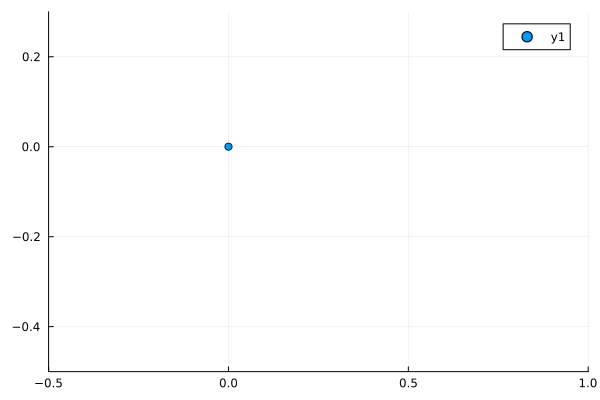

In [153]:
scatter(real(val),imag(val),xlims=[-0.5,1],ylims=[-0.5,0.3])